In [9]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [13]:
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

In [14]:
df = pd.DataFrame(data)
print(df.head())

                                              Review
0  The product quality is excellent and delivery ...
1       Very bad packaging and the item was damaged.
2       Customer service was helpful and responsive.
3  The delivery was delayed and support team did ...
4                  Amazing product. Worth the money.


In [15]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    #convert to lowercase
    text = text.lower()
    print('lower case', text)

    #remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    print('special character', text)

    #tokenization
    words = word_tokenize(text)
    print('tokenization', words)

    #remove stopwords
    words = [word for word in words if word not in stop_words]
    print('stopwords', words)

    #join words again
    cleaned_text = " ".join(words)

    return cleaned_text

#Apply cleaning function
df['cleaned_review'] = df['Review'].apply(clean_text)

print("\nCleaned Reviews")
print(df[['Review', 'cleaned_review']])

lower case the product quality is excellent and delivery was very fast.
special character the product quality is excellent and delivery was very fast
tokenization ['the', 'product', 'quality', 'is', 'excellent', 'and', 'delivery', 'was', 'very', 'fast']
stopwords ['product', 'quality', 'excellent', 'delivery', 'fast']
lower case very bad packaging and the item was damaged.
special character very bad packaging and the item was damaged
tokenization ['very', 'bad', 'packaging', 'and', 'the', 'item', 'was', 'damaged']
stopwords ['bad', 'packaging', 'item', 'damaged']
lower case customer service was helpful and responsive.
special character customer service was helpful and responsive
tokenization ['customer', 'service', 'was', 'helpful', 'and', 'responsive']
stopwords ['customer', 'service', 'helpful', 'responsive']
lower case the delivery was delayed and support team did not respond.
special character the delivery was delayed and support team did not respond
tokenization ['the', 'delivery'

In [24]:
sia = SentimentIntensityAnalyzer()
def analye_sentiment(text):
  score = sia.polarity_scores(text)
  compound = score['compound']
  if compound >= 0.05:
    return 'positive'
  elif compound <= -0.05:
    return 'negative'
  else:
    return 'neutral'

df['sentiment'] = df['cleaned_review'].apply(analye_sentiment)
print("\nSentiment Analysis results")
print(df[['Review','sentiment']])


Sentiment Analysis results
                                              Review sentiment
0  The product quality is excellent and delivery ...  positive
1       Very bad packaging and the item was damaged.  negative
2       Customer service was helpful and responsive.  positive
3  The delivery was delayed and support team did ...  positive
4                  Amazing product. Worth the money.  positive
5      Poor quality product and terrible experience.  negative
6                  Fast shipping and good packaging.  positive
7        The product stopped working after two days.  negative
8               Excellent service and great quality.  positive
9            Late delivery and bad customer support.  negative


In [23]:
all_words = " ".join(df['cleaned_review'])
word_list = all_words.split()
word_freq = Counter(word_list)
print("\n top 10 common keywords")
print(word_freq.most_common(10))


 top 10 common keywords
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


In [25]:
negative_reviews = df[df['sentiment'] == 'negative']
negative_words = " ".join(negative_reviews['cleaned_review'])
negative_word_list = negative_words.split()
complaint_freq = Counter(negative_word_list)
print("\n not common complaint keywords")
print(complaint_freq.most_common(10))


 not common complaint keywords
[('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


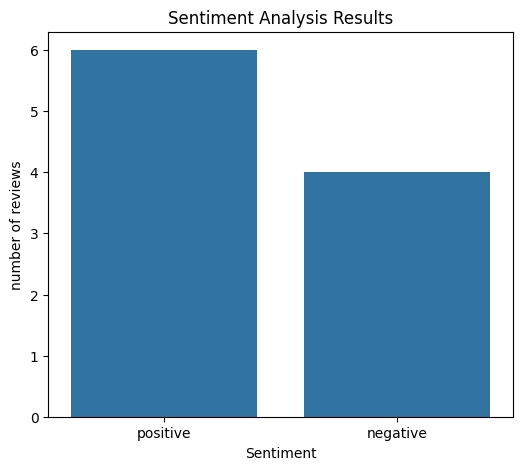

In [29]:
sentiment_counts = df['sentiment'].value_counts()
plt.figure(figsize=(6, 5))
sns.barplot(x=sentiment_counts.index,y=sentiment_counts.values)
plt.title('Sentiment Analysis Results')
plt.xlabel('Sentiment')
plt.ylabel('number of reviews')
plt.show()

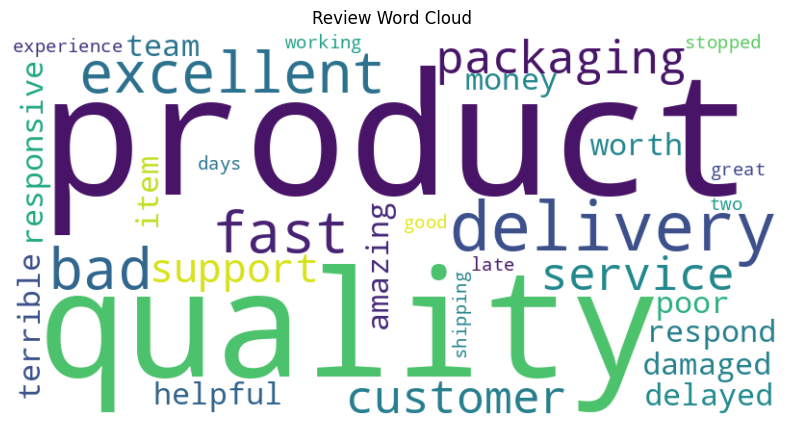

In [30]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Review Word Cloud ')
plt.show()